# Consumer Price Index

In [ ]:
import pandas as pd
import csv
import numpy as np
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', None)


## Get Data

In [2]:
def getData(file):
    fin=open(file)
    lines=fin.readlines()
    return lines

current=getData("cu.data.0.Current")
#allItems=getData("cu.data.1.AllItems")
df=pd.read_csv("cu.data.0.Current",delimiter="\t")
df.columns = df.columns.str.strip()

In [ ]:
df.

In [8]:
df.columns

Index(['series_id', 'year', 'period', 'value', 'footnote_codes'], dtype='object')

## Functions

In [5]:
def colsToDict(df,key,val,fmt={}):
    return df.set_index(key)[val].to_dict()

def countDict(key,dct): 
    if key in dct:
        dct[key]+=1
    else:
        dct[key]=1

def decodeCUSeries(series):
    
    if series[0:2] == "CU":
       srs=series[2:]
    else:
       srs=series

    season=srs[0:1]
    period=srs[1:2]
    area=srs[2:6]
    item=srs[6:14].strip()
    
    return season,period,area,item

    
def createInvt(year,mon,invt):
    if year not in invt:
        invt[year]={}
    if mon not in invt[year]:
        invt[year][mon]=0
    invt[year][mon]+=1
    

## Get Definitions

In [6]:
defAre = pd.read_csv("cu.area",delimiter="\t")
defAre = colsToDict(defAre,"area_code","area_name")

defItem = pd.read_csv("cu.item",delimiter="\t")
defItem = colsToDict(defItem,"item_code","item_name")

defPer = pd.read_csv("cu.periodicity",delimiter="\t")
defPer = colsToDict(defPer,"periodicity_code","periodicity_name")

defSea = pd.read_csv("cu.seasonal",delimiter="\t")
defSea = colsToDict(defSea,"seasonal_code","seasonal_text")

defSer = pd.read_csv("cu.series",delimiter="\t")
defSer.columns=defSer.columns.str.strip()
defSer = colsToDict(defSer,"series_id","series_title")

In [9]:
df['area'] = df["series_id"].str[4:8]
df['season'] = df["series_id"].str[2:3]
df['periodicity'] = df["series_id"].str[3:4]
df['item'] = df["series_id"].str[8:16].str.strip()



## Subset Colorado Data

In [10]:
dfC = df.loc[df["area"]=="S48B"]
dfC["areaName"] = dfC["area"].map(defAre)
dfC["seasonName"] = dfC["season"].map(defSea)
dfC["periodicityName"] = dfC["periodicity"].map(defPer)
dfC["itemName"] = dfC["item"].map(defItem)


/tmp/ipykernel_29329/911342131.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfC["areaName"] = dfC["area"].map(defAre)
/tmp/ipykernel_29329/911342131.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfC["seasonName"] = dfC["season"].map(defSea)
/tmp/ipykernel_29329/911342131.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [8]:
dfC["item"].map(defItem)

818759           All items - old base
818760           All items - old base
818761           All items - old base
818762           All items - old base
818763           All items - old base
                      ...            
1068905    Gasoline, unleaded premium
1068906    Gasoline, unleaded premium
1068907    Gasoline, unleaded premium
1068908    Gasoline, unleaded premium
1068909    Gasoline, unleaded premium
Name: item, Length: 8010, dtype: object

In [9]:
print(dfC["periodicityName"].value_counts())
print(dfC["periodicity"].value_counts())


periodicityName
Semi-Annual    4255
Monthly        3755
Name: count, dtype: int64
periodicity
S    4255
R    3755
Name: count, dtype: int64


In [10]:
dfC["period"].value_counts()


period
S03    1419
S02    1419
S01    1417
M01     477
M11     464
M13     432
M05     423
M03     423
M07     420
M09     415
M12     132
M08     115
M06     115
M10     115
M02     112
M04     112
Name: count, dtype: int64

period
SEMI-ANNUAL
    S02    1419
    S03    1419
    S01    1417

MONTHLY
    M01     477
    M03     423
    M05     423   
    M07     420
    M09     415
    M11     464
    M13     432
   
BI-MONTHLY    
    M02     112
    M04     112
    M06     115
    M08     115
    M10     115
    M12     132

### Split into Monthly and Semi-Annual

In [11]:
dfCSemiA=dfC.loc[dfC["periodicity"] == "S"]
dfCMnly=dfC.loc[dfC["periodicity"] == "R"]
print(dfCSemiA.shape)
print(dfCMnly.shape)


(4255, 13)
(3755, 13)


In [13]:
display(df.head())

,series_id,year,period,value,footnote_codes,area,season,periodicity,item
0,CUSR0000SA0,1997,M01,159.4,NaN,0000,S,R,SA0
1,CUSR0000SA0,1997,M02,159.7,NaN,0000,S,R,SA0
2,CUSR0000SA0,1997,M03,159.8,NaN,0000,S,R,SA0
3,CUSR0000SA0,1997,M04,159.9,NaN,0000,S,R,SA0
4,CUSR0000SA0,1997,M05,159.9,NaN,0000,S,R,SA0


### Transform

In [15]:
data={}
dfCMnly.sort_values(by=["year","period"],inplace=True)
items=list(dfCMnly["itemName"].value_counts().to_dict().keys())
items.sort()
years=sorted(dfCMnly["year"].value_counts().to_dict().keys())
heads=["series","year","month"]
for h in heads:
    data[h]=[]
for item in items:
    data[item]=[]

for year in years:    
    if year > 2000: 
        tmp=dfCMnly.loc[dfCMnly["year"]== year]
        for pp in sorted(tmp["period"].value_counts().to_dict().keys()):
            if pp.upper() != "M13":
                hld=tmp.loc[tmp["period"] == pp]
        
                dct=hld.set_index("itemName")["value"].to_dict()
                srs=hld["series_id"].values[0]
                srs=srs[:8]
                data["series"].append(srs)
                data["year"].append(year)
                period=pp.upper().strip("M")
                data["month"].append(period)
                
                for item in items:
                    if item in dct:
                        val=dct[item]
                    else:
                        val=""
                    data[item].append(val)

/tmp/ipykernel_823/2018842849.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfCMnly.sort_values(by=["year","period"],inplace=True)


In [18]:
cuOutput=pd.DataFrame(data)

In [19]:
cuOutput.isna().sum()

series                                           0
year                                             0
month                                            0
Alcoholic beverages                              0
All items                                        0
All items - old base                             0
All items less energy                            0
All items less food and energy                   0
All items less medical care                      0
All items less shelter                           0
Apparel                                          0
Cereals and bakery products                      0
Commodities                                      0
Commodities less food                            0
Commodities less food and beverages              0
Dairy and related products                       0
Durables                                         0
Education and communication                      0
Education and communication commodities          0
Education and communication ser

In [89]:
cuOutput.columns

Index(['series', 'year', 'month', 'Alcoholic beverages', 'All items',
       'All items - old base', 'All items less energy',
       'All items less food and energy', 'All items less medical care',
       'All items less shelter', 'Apparel', 'Cereals and bakery products',
       'Commodities', 'Commodities less food',
       'Commodities less food and beverages', 'Dairy and related products',
       'Durables', 'Education and communication',
       'Education and communication commodities',
       'Education and communication services', 'Electricity', 'Energy',
       'Energy services', 'Food', 'Food and beverages', 'Food at home',
       'Food away from home', 'Fruits and vegetables', 'Fuels and utilities',
       'Gasoline (all types)', 'Gasoline, unleaded midgrade',
       'Gasoline, unleaded premium', 'Gasoline, unleaded regular',
       'Household energy', 'Household furnishings and operations',
       'Household furnishings and supplies', 'Housing',
       'Meats, poultry, fish, 

### Output to File

In [14]:
cuOutput.to_csv("cu.mnthly.tsv",sep="\t",index=False)

In [21]:
cuOutput.groupby("month").count()

,series,year,Alcoholic beverages,All items,All items - old base,All items less energy,All items less food and energy,All items less medical care,All items less shelter,Apparel,Cereals and bakery products,Commodities,Commodities less food,Commodities less food and beverages,Dairy and related products,Durables,Education and communication,Education and communication commodities,Education and communication services,Electricity,Energy,Energy services,Food,Food and beverages,Food at home,Food away from home,Fruits and vegetables,Fuels and utilities,Gasoline (all types),"Gasoline, unleaded midgrade","Gasoline, unleaded premium","Gasoline, unleaded regular",Household energy,Household furnishings and operations,Household furnishings and supplies,Housing,"Meats, poultry, fish, and eggs",Medical care,Motor fuel,Motor vehicle insurance,New and used motor vehicles,New vehicles,Nonalcoholic beverages and beverage materials,Nondurables,Nondurables less food,Nondurables less food and beverages,Other food at home,Other goods,Other goods and services,Other personal services,Owners' equivalent rent of primary residence,Owners' equivalent rent of residences,Private transportation,Recreation,Rent of primary residence,Services,Services less medical care services,Services less rent of shelter,Shelter,Transportation,Transportation commodities less motor fuel,"Tuition, other school fees, and childcare",Used cars and trucks,Utility (piped) gas service
month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
01,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8,8
02,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
03,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
04,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
05,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
06,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
07,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
08,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
09,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7


In [24]:
tmp=cuOutput.replace("",np.nan)

/tmp/ipykernel_823/2429296455.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tmp=cuOutput.replace("",np.nan)


In [78]:
tmp.head()

,series,year,month,Alcoholic beverages,All items,All items - old base,All items less energy,All items less food and energy,All items less medical care,All items less shelter,Apparel,Cereals and bakery products,Commodities,Commodities less food,Commodities less food and beverages,Dairy and related products,Durables,Education and communication,Education and communication commodities,Education and communication services,Electricity,Energy,Energy services,Food,Food and beverages,Food at home,Food away from home,Fruits and vegetables,Fuels and utilities,Gasoline (all types),"Gasoline, unleaded midgrade","Gasoline, unleaded premium","Gasoline, unleaded regular",Household energy,Household furnishings and operations,Household furnishings and supplies,Housing,"Meats, poultry, fish, and eggs",Medical care,Motor fuel,Motor vehicle insurance,New and used motor vehicles,New vehicles,Nonalcoholic beverages and beverage materials,Nondurables,Nondurables less food,Nondurables less food and beverages,Other food at home,Other goods,Other goods and services,Other personal services,Owners' equivalent rent of primary residence,Owners' equivalent rent of residences,Private transportation,Recreation,Rent of primary residence,Services,Services less medical care services,Services less rent of shelter,Shelter,Transportation,Transportation commodities less motor fuel,"Tuition, other school fees, and childcare",Used cars and trucks,Utility (piped) gas service
0,CUURS48B,2017,11,199.143,258.614,862.370,266.744,273.466,243.847,239.373,108.494,287.129,170.019,141.740,139.368,192.806,108.119,121.379,77.408,105.855,NaN,NaN,NaN,234.003,230.273,NaN,246.378,278.971,234.775,NaN,NaN,NaN,NaN,NaN,115.566,95.936,258.533,211.996,581.482,NaN,2576.607,107.209,222.019,149.541,200.717,172.215,170.321,199.933,100.798,356.816,121.920,NaN,NaN,243.932,160.253,NaN,337.101,316.248,387.321,NaN,250.510,102.736,1029.430,252.850,NaN
1,CUURS48B,2017,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.618,181.894,164.613,NaN,NaN,227.002,NaN,NaN,NaN,204.922,205.385,228.050,198.107,165.827,NaN,NaN,NaN,NaN,NaN,206.684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,294.295,294.295,NaN,NaN,310.533,NaN,NaN,NaN,300.951,NaN,NaN,NaN,NaN,155.366
2,CUURS48B,2018,01,199.266,259.907,866.683,268.444,274.840,244.769,239.598,107.158,288.037,170.404,140.986,138.590,196.493,108.027,121.326,77.862,105.739,167.618,181.422,167.312,237.612,233.591,229.515,248.356,288.881,242.757,201.400,202.702,224.493,194.613,168.526,116.116,96.503,261.852,216.979,592.008,203.212,2569.417,107.538,219.569,151.084,201.536,170.913,168.921,205.495,100.231,359.528,123.793,295.877,295.877,241.435,159.126,312.501,339.278,317.769,387.585,302.576,244.822,102.887,1026.561,258.097,169.254
3,CUURS48B,2018,02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167.618,181.605,167.312,NaN,NaN,228.657,NaN,NaN,NaN,201.753,201.786,224.824,195.014,168.626,NaN,NaN,NaN,NaN,NaN,203.483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295.706,295.706,NaN,NaN,312.817,NaN,NaN,NaN,300.242,NaN,NaN,NaN,NaN,169.254
4,CUURS48B,2018,03,199.174,260.595,868.977,269.088,275.088,245.450,241.173,101.932,290.897,170.714,140.409,138.002,197.267,107.976,121.137,77.387,105.621,167.618,182.669,167.313,240.644,236.353,230.961,253.336,285.531,246.663,203.830,204.260,226.632,197.084,168.680,116.003,96.384,261.308,215.208,592.716,205.551,2569.417,107.701,216.922,156.053,202.101,169.683,167.612,209.194,99.290,358.660,124.028,296.313,296.313,245.123,161.240,313.828,340.321,318.825,392.270,301.397,249.218,103.526,1023.266,263.311,169.257


In [28]:
tmp2=tmp.groupby(["year","month"],as_index=False).count()

In [35]:
tmp3=tmp2.sum().to_dict()

In [38]:
del tmp3["year"]
del tmp3["month"]


In [46]:
for k,v in sorted(tmp3.items(),key=lambda item: item[1],reverse=True):
    print(f"{v:3d}  {k}")

 87  series
 86  Energy
 86  Food at home
 86  Gasoline (all types)
 86  Gasoline, unleaded midgrade
 86  Gasoline, unleaded premium
 86  Gasoline, unleaded regular
 86  Motor fuel
 86  Owners' equivalent rent of primary residence
 86  Owners' equivalent rent of residences
 86  Rent of primary residence
 86  Shelter
 78  Electricity
 78  Energy services
 78  Household energy
 60  Cereals and bakery products
 60  Dairy and related products
 60  Fruits and vegetables
 60  Meats, poultry, fish, and eggs
 60  Nonalcoholic beverages and beverage materials
 60  Other food at home
 44  Alcoholic beverages
 44  All items
 44  All items - old base
 44  All items less energy
 44  All items less food and energy
 44  All items less medical care
 44  All items less shelter
 44  Apparel
 44  Commodities
 44  Commodities less food
 44  Commodities less food and beverages
 44  Durables
 44  Education and communication
 44  Education and communication commodities
 44  Education and communication servic

In [75]:
for k,v in sorted(tmp3.items(),key=lambda item: item[1],reverse=True):
    print(f"- {k}")

- series
- Energy
- Food at home
- Gasoline (all types)
- Gasoline, unleaded midgrade
- Gasoline, unleaded premium
- Gasoline, unleaded regular
- Motor fuel
- Owners' equivalent rent of primary residence
- Owners' equivalent rent of residences
- Rent of primary residence
- Shelter
- Electricity
- Energy services
- Household energy
- Cereals and bakery products
- Dairy and related products
- Fruits and vegetables
- Meats, poultry, fish, and eggs
- Nonalcoholic beverages and beverage materials
- Other food at home
- Alcoholic beverages
- All items
- All items - old base
- All items less energy
- All items less food and energy
- All items less medical care
- All items less shelter
- Apparel
- Commodities
- Commodities less food
- Commodities less food and beverages
- Durables
- Education and communication
- Education and communication commodities
- Education and communication services
- Food
- Food and beverages
- Food away from home
- Household furnishings and operations
- Household furn

### Create Dictionary

In [74]:
display(tmp2.head(200))

,year,month,series,Alcoholic beverages,All items,All items - old base,All items less energy,All items less food and energy,All items less medical care,All items less shelter,Apparel,Cereals and bakery products,Commodities,Commodities less food,Commodities less food and beverages,Dairy and related products,Durables,Education and communication,Education and communication commodities,Education and communication services,Electricity,Energy,Energy services,Food,Food and beverages,Food at home,Food away from home,Fruits and vegetables,Fuels and utilities,Gasoline (all types),"Gasoline, unleaded midgrade","Gasoline, unleaded premium","Gasoline, unleaded regular",Household energy,Household furnishings and operations,Household furnishings and supplies,Housing,"Meats, poultry, fish, and eggs",Medical care,Motor fuel,Motor vehicle insurance,New and used motor vehicles,New vehicles,Nonalcoholic beverages and beverage materials,Nondurables,Nondurables less food,Nondurables less food and beverages,Other food at home,Other goods,Other goods and services,Other personal services,Owners' equivalent rent of primary residence,Owners' equivalent rent of residences,Private transportation,Recreation,Rent of primary residence,Services,Services less medical care services,Services less rent of shelter,Shelter,Transportation,Transportation commodities less motor fuel,"Tuition, other school fees, and childcare",Used cars and trucks,Utility (piped) gas service
0,2017,11,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,1,1,0,1,1,1,0,0,0,0,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,0,0,1,1,0,1,1,1,0,1,1,1,1,0
1,2017,12,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,1
2,2018,01,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
3,2018,02,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,1
4,2018,03,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
5,2018,04,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,1
6,2018,05,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
7,2018,06,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,1
8,2018,07,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
9,2018,08,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,1,0,0,0,1,1,1,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,1,0,0,0,0,1


In [73]:
xrefs = {
'series':'series',
'year':'year',
'month':'month',
'alchBevs':'Alcoholic beverages',
'allItm':'All items',
'allItmOldBase':'All items - old base',
'allItmLsEnergy':'All items less energy',
'allItmLsFoodEnergy':'All items less food and energy',
'allItmLsMedCare':'All items less medical care',
'allItmLsShelter':'All items less shelter',
'apparel':'Apparel',
'cerlsBkryProd':'Cereals and bakery products',
'commod':'Commodities',
'commodLsFood':'Commodities less food',
'commodLsFoodBevs':'Commodities less food and beverages',
'dairyRelatedProds':'Dairy and related products',
'durables':'Durables',
'eduCommun':'Education and communication',
'eduCommunCommod':'Education and communication commodities',
'eduCommunSrvc':'Education and communication services',
'electricity':'Electricity',
'energy':'Energy',
'energySrvc':'Energy services',
'food':'Food',
'foodBevs':'Food and beverages',
'foodAtHome':'Food at home',
'foodAwayFromHome':'Food away from home',
'fruitsVegs':'Fruits and vegetables',
'fuelsUtils':'Fuels and utilities',
'gasAllTypes':'Gasoline (all types)',
'gasUnleadMid':'Gasoline, unleaded midgrade',
'gasUnleadPrem':'Gasoline, unleaded premium',
'gasUnleadReg':'Gasoline, unleaded regular',
'householdEnergy':'Household energy',
'householdFurnOps':'Household furnishings and operations',
'householdFurnSup':'Household furnishings and supplies',
'housing':'Housing',
'meatsPoulFishEggs':'Meats, poultry, fish, and eggs',
'medicalCare':'Medical care',
'motorFuel':'Motor fuel',
'motorVehclIns':'Motor vehicle insurance',
'newUsedMotorVehcl':'New and used motor vehicles',
'newVehcl':'New vehicles',
'nonalchBevsMatrl':'Nonalcoholic beverages and beverage materials',
'nondur':'Nondurables',
'nondurLessFood':'Nondurables less food',
'nondurLessFoodBevs':'Nondurables less food and beverages',
'otherFoodAtHome':'Other food at home',
'otherGoods':'Other goods',
'otherGoodsSrvcs':'Other goods and services',
'otherPersSrvcs':'Other personal services',
'ownEquivRentPrimRes':"Owners' equivalent rent of primary residence",
'ownEquivRentRes':"Owners' equivalent rent of residences",
'privateTrans':'Private transportation',
'recreation':'Recreation',
'rentPrimRes':'Rent of primary residence',
'srvcs':'Services',
'srvcsLessMedCareSrvcs':'Services less medical care services',
'srvcsLessRentOfShelter':'Services less rent of shelter',
'shelter':'Shelter',
'trans':'Transportation',
'transCommsLessMotorFuel':'Transportation commodities less motor fuel',
'tuitOtherSchlFeesChldcr':'Tuition, other school fees, and childcare',
'usedCarsTrucks':'Used cars and trucks',
'utilGasSrvc':'Utility (piped) gas service'
}

xrefsX={val:key for key,val in xrefs.items()}

In [126]:
len(xrefs)

65

In [135]:
for k,v in sorted(xrefs.items()):
    print(f"{k}")

alchBevs
allItm
allItmLsEnergy
allItmLsFoodEnergy
allItmLsMedCare
allItmLsShelter
allItmOldBase
apparel
cerlsBkryProd
commod
commodLsFood
commodLsFoodBevs
dairyRelatedProds
durables
eduCommun
eduCommunCommod
eduCommunSrvc
electricity
energy
energySrvc
food
foodAtHome
foodAwayFromHome
foodBevs
fruitsVegs
fuelsUtils
gasAllTypes
gasUnleadMid
gasUnleadPrem
gasUnleadReg
householdEnergy
householdFurnOps
householdFurnSup
housing
meatsPoulFishEggs
medicalCare
month
motorFuel
motorVehclIns
newUsedMotorVehcl
newVehcl
nonalchBevsMatrl
nondur
nondurLessFood
nondurLessFoodBevs
otherFoodAtHome
otherGoods
otherGoodsSrvcs
otherPersSrvcs
ownEquivRentPrimRes
ownEquivRentRes
privateTrans
recreation
rentPrimRes
series
shelter
srvcs
srvcsLessMedCareSrvcs
srvcsLessRentOfShelter
trans
transCommsLessMotorFuel
tuitOtherSchlFeesChldcr
usedCarsTrucks
utilGasSrvc
year


In [74]:
import datetime
tday= datetime.datetime.today().strftime("%Y-%m-%d")
lookup={"eudi-jgs4":{}}
ftmp=open("tmp.txt","w")
for item in itemsC:
    name=defItem[item]
   
    if name in xrefsX:
       lookup["eudi-jgs4"][item]={}
       lookup["eudi-jgs4"][item]["xref"]=xrefsX[name]
       lookup["eudi-jgs4"][item]["desc"]=name        
       lookup["eudi-jgs4"][item]["date"]=tday
       lookup["eudi-jgs4"][item]["notes"]=""
       ftmp.write(f"{xrefsX[name]:30s}   {name}\n")
    else:
       print("Miss ",name)

ftmp.close()

In [ ]:
json.dumps(lookup)

In [76]:
import json
fout=open("bls_cu_eudi-jgs4_src_trns_xrefs.json","w")
json.dump(lookup,fout,indent=4)
fout.close()

In [104]:
import sys,os
sys.path.insert(0, os.path.join("/home/joe/bic_etl", 'general', 'scripts'))
from datasetFuncs import *
fieldXrefs = getSrcTrnsDict("/home/joe/bic_etl/bls/defs","bls_cu_eudi-jgs4_src_trns_xrefs.json","eudi-jgs4")

In [141]:
for key,val in sorted(fieldXrefs.items(),key=lambda item: item[1]):
    print(f"{key:20s} {val}")

SAF116               alchBevs
SA0                  allItm
SA0LE                allItmLsEnergy
SA0L1E               allItmLsFoodEnergy
SA0L5                allItmLsMedCare
SA0L2                allItmLsShelter
AA0                  allItmOldBase
SAA                  apparel
SAF111               cerlsBkryProd
SAC                  commod
SACL1                commodLsFood
SACL11               commodLsFoodBevs
SEFJ                 dairyRelatedProds
SAD                  durables
SAE                  eduCommun
SAEC                 eduCommunCommod
SAES                 eduCommunSrvc
SEHF01               electricity
SA0E                 energy
SEHF                 energySrvc
SAF1                 food
SAF11                foodAtHome
SEFV                 foodAwayFromHome
SAF                  foodBevs
SAF113               fruitsVegs
SAH2                 fuelsUtils
SETB01               gasAllTypes
SS47015              gasUnleadMid
SS47016              gasUnleadPrem
SS47014              gasUnleadReg
SA

In [108]:
  [col for col in cuOutput.columns  if col in fieldXrefs]

[]

### Check Monthly

In [109]:
new=pd.read_csv("cu.mnthly.tsv",delimiter="\t")

In [110]:
new.columns

Index(['series', 'year', 'month', 'Alcoholic beverages', 'All items',
       'All items - old base', 'All items less energy',
       'All items less food and energy', 'All items less medical care',
       'All items less shelter', 'Apparel', 'Cereals and bakery products',
       'Commodities', 'Commodities less food',
       'Commodities less food and beverages', 'Dairy and related products',
       'Durables', 'Education and communication',
       'Education and communication commodities',
       'Education and communication services', 'Electricity', 'Energy',
       'Energy services', 'Food', 'Food and beverages', 'Food at home',
       'Food away from home', 'Fruits and vegetables', 'Fuels and utilities',
       'Gasoline (all types)', 'Gasoline, unleaded midgrade',
       'Gasoline, unleaded premium', 'Gasoline, unleaded regular',
       'Household energy', 'Household furnishings and operations',
       'Household furnishings and supplies', 'Housing',
       'Meats, poultry, fish, 

In [16]:
fin=open("cu.data.0.Current")
reader=csv.DictReader(fin,delimiter="\t")
origCoRows=[]
origCoData={}
for row in reader:
    srs=row['series_id        '].strip()
    season,periodicity,area,item = decodeCUSeries(srs)
    year=int(row["year"])
   
    if area =="S48B" and periodicity == "R" and period != "M13":
       per = int(row["period"].upper().strip("M"))
       origCoRows.append(row)
       if year not in origCoData:
           origCoData[year]={}
       if per not in origCoData[year]:
           origCoData[year][per]={}
       itm = defItem[item]
       origCoData[year][per][itm]=row['       value']

In [17]:
hist={}
for year,dct in sorted(origCoData.items()):
    if year > 2000:
        if year not in hist:
            hist[year]={}
        for month,dct2 in sorted(dct.items()):
            if month < 13: 
                if month not in hist[year]:
                    hist[year][month]={}
                    hist[year][month]["good"]=0
                    hist[year][month]["bad"]=0
                    
               
                tmp=new.loc[(new["year"] == int(year)) & (new["month"] == int(month))].to_dict(orient="records")
                for key,valO in dct2.items():
                    valT=float(tmp[0][key])
                    valO=float(valO)
                    if valO != valT:
                        print(year,month,key,valO,valT)
                        hist[year][month]["bad"]+=1                      
                    else:
                        hist[year][month]["good"]+=1
     

In [18]:
for year,dct in sorted(hist.items()):
    for month,dct2 in sorted(dct.items()):
        print(f"{year:4d}  {month:2d}   {dct2['good']:3d}  {dct2['bad']:3d}")

2017  11    47    0
2017  12    15    0
2018   1    62    0
2018   2    15    0
2018   3    62    0
2018   4    15    0
2018   5    62    0
2018   6    15    0
2018   7    62    0
2018   8    15    0
2018   9    62    0
2018  10    15    0
2018  11    62    0
2018  12    15    0
2019   1    62    0
2019   2    15    0
2019   3    62    0
2019   4    15    0
2019   5    62    0
2019   6    15    0
2019   7    62    0
2019   8    15    0
2019   9    62    0
2019  10    15    0
2019  11    62    0
2019  12    15    0
2020   1    61    0
2020   2    14    0
2020   3    61    0
2020   4    14    0
2020   5    61    0
2020   6    14    0
2020   7    61    0
2020   8    14    0
2020   9    61    0
2020  10    14    0
2020  11    61    0
2020  12    14    0
2021   1    61    0
2021   2    14    0
2021   3    61    0
2021   4    14    0
2021   5    58    0
2021   6    14    0
2021   7    61    0
2021   8    14    0
2021   9    57    0
2021  10    14    0
2021  11    58    0
2021  12    14    0


In [19]:
new.dtypes

series                                            object
year                                               int64
month                                              int64
Alcoholic beverages                              float64
All items                                        float64
All items - old base                             float64
All items less energy                            float64
All items less food and energy                   float64
All items less medical care                      float64
All items less shelter                           float64
Apparel                                          float64
Cereals and bakery products                      float64
Commodities                                      float64
Commodities less food                            float64
Commodities less food and beverages              float64
Dairy and related products                       float64
Durables                                         float64
Education and communication    

In [20]:
dfCMnly.groupby(["year","period"])["period"].count()

year  period
1997  M12        2
2017  M11       47
      M12       15
      M13       11
2018  M01       62
      M02       15
      M03       62
      M04       15
      M05       62
      M06       15
      M07       62
      M08       15
      M09       62
      M10       15
      M11       62
      M12       15
      M13       62
2019  M01       62
      M02       15
      M03       62
      M04       15
      M05       62
      M06       15
      M07       62
      M08       15
      M09       62
      M10       15
      M11       62
      M12       15
      M13       62
2020  M01       61
      M02       14
      M03       61
      M04       14
      M05       61
      M06       14
      M07       61
      M08       14
      M09       61
      M10       14
      M11       61
      M12       14
      M13       61
2021  M01       61
      M02       14
      M03       61
      M04       14
      M05       58
      M06       14
      M07       61
      M08       14
      M09       57

In [22]:
cuOutput.shape

(87, 65)

In [15]:
cuOutput.head()


,series,year,month,Alcoholic beverages,All items,All items - old base,All items less energy,All items less food and energy,All items less medical care,All items less shelter,Apparel,Cereals and bakery products,Commodities,Commodities less food,Commodities less food and beverages,Dairy and related products,Durables,Education and communication,Education and communication commodities,Education and communication services,Electricity,Energy,Energy services,Food,Food and beverages,Food at home,Food away from home,Fruits and vegetables,Fuels and utilities,Gasoline (all types),"Gasoline, unleaded midgrade","Gasoline, unleaded premium","Gasoline, unleaded regular",Household energy,Household furnishings and operations,Household furnishings and supplies,Housing,"Meats, poultry, fish, and eggs",Medical care,Motor fuel,Motor vehicle insurance,New and used motor vehicles,New vehicles,Nonalcoholic beverages and beverage materials,Nondurables,Nondurables less food,Nondurables less food and beverages,Other food at home,Other goods,Other goods and services,Other personal services,Owners' equivalent rent of primary residence,Owners' equivalent rent of residences,Private transportation,Recreation,Rent of primary residence,Services,Services less medical care services,Services less rent of shelter,Shelter,Transportation,Transportation commodities less motor fuel,"Tuition, other school fees, and childcare",Used cars and trucks,Utility (piped) gas service
0,CUURS48B,2017,11,199.143,258.614,862.37,266.744,273.466,243.847,239.373,108.494,287.129,170.019,141.74,139.368,192.806,108.119,121.379,77.408,105.855,,,,234.003,230.273,,246.378,278.971,234.775,,,,,,115.566,95.936,258.533,211.996,581.482,,2576.607,107.209,222.019,149.541,200.717,172.215,170.321,199.933,100.798,356.816,121.92,,,243.932,160.253,,337.101,316.248,387.321,,250.51,102.736,1029.43,252.85,
1,CUURS48B,2017,12,,,,,,,,,,,,,,,,,,170.618,181.894,164.613,,,227.002,,,,204.922,205.385,228.05,198.107,165.827,,,,,,206.684,,,,,,,,,,,,294.295,294.295,,,310.533,,,,300.951,,,,,155.366
2,CUURS48B,2018,01,199.266,259.907,866.683,268.444,274.84,244.769,239.598,107.158,288.037,170.404,140.986,138.59,196.493,108.027,121.326,77.862,105.739,167.618,181.422,167.312,237.612,233.591,229.515,248.356,288.881,242.757,201.4,202.702,224.493,194.613,168.526,116.116,96.503,261.852,216.979,592.008,203.212,2569.417,107.538,219.569,151.084,201.536,170.913,168.921,205.495,100.231,359.528,123.793,295.877,295.877,241.435,159.126,312.501,339.278,317.769,387.585,302.576,244.822,102.887,1026.561,258.097,169.254
3,CUURS48B,2018,02,,,,,,,,,,,,,,,,,,167.618,181.605,167.312,,,228.657,,,,201.753,201.786,224.824,195.014,168.626,,,,,,203.483,,,,,,,,,,,,295.706,295.706,,,312.817,,,,300.242,,,,,169.254
4,CUURS48B,2018,03,199.174,260.595,868.977,269.088,275.088,245.45,241.173,101.932,290.897,170.714,140.409,138.002,197.267,107.976,121.137,77.387,105.621,167.618,182.669,167.313,240.644,236.353,230.961,253.336,285.531,246.663,203.83,204.26,226.632,197.084,168.68,116.003,96.384,261.308,215.208,592.716,205.551,2569.417,107.701,216.922,156.053,202.101,169.683,167.612,209.194,99.29,358.66,124.028,296.313,296.313,245.123,161.24,313.828,340.321,318.825,392.27,301.397,249.218,103.526,1023.266,263.311,169.257


In [ ]:
cuOutput.groupby(["year","month"])["series"].count()

In [49]:
test=cuOutput.copy()
#test["date"]=cuOutput["year"].astype(str)+"/"+cuOutput["month"].astype(str)

In [50]:
test.head()

,series,year,month,Alcoholic beverages,All items,All items - old base,All items less energy,All items less food and energy,All items less medical care,All items less shelter,Apparel,Cereals and bakery products,Commodities,Commodities less food,Commodities less food and beverages,Dairy and related products,Durables,Education and communication,Education and communication commodities,Education and communication services,Electricity,Energy,Energy services,Food,Food and beverages,Food at home,Food away from home,Fruits and vegetables,Fuels and utilities,Gasoline (all types),"Gasoline, unleaded midgrade","Gasoline, unleaded premium","Gasoline, unleaded regular",Household energy,Household furnishings and operations,Household furnishings and supplies,Housing,"Meats, poultry, fish, and eggs",Medical care,Motor fuel,Motor vehicle insurance,New and used motor vehicles,New vehicles,Nonalcoholic beverages and beverage materials,Nondurables,Nondurables less food,Nondurables less food and beverages,Other food at home,Other goods,Other goods and services,Other personal services,Owners' equivalent rent of primary residence,Owners' equivalent rent of residences,Private transportation,Recreation,Rent of primary residence,Services,Services less medical care services,Services less rent of shelter,Shelter,Transportation,Transportation commodities less motor fuel,"Tuition, other school fees, and childcare",Used cars and trucks,Utility (piped) gas service
0,CUURS48B,2017,11,199.143,258.614,862.37,266.744,273.466,243.847,239.373,108.494,287.129,170.019,141.74,139.368,192.806,108.119,121.379,77.408,105.855,,,,234.003,230.273,,246.378,278.971,234.775,,,,,,115.566,95.936,258.533,211.996,581.482,,2576.607,107.209,222.019,149.541,200.717,172.215,170.321,199.933,100.798,356.816,121.92,,,243.932,160.253,,337.101,316.248,387.321,,250.51,102.736,1029.43,252.85,
1,CUURS48B,2017,12,,,,,,,,,,,,,,,,,,170.618,181.894,164.613,,,227.002,,,,204.922,205.385,228.05,198.107,165.827,,,,,,206.684,,,,,,,,,,,,294.295,294.295,,,310.533,,,,300.951,,,,,155.366
2,CUURS48B,2018,01,199.266,259.907,866.683,268.444,274.84,244.769,239.598,107.158,288.037,170.404,140.986,138.59,196.493,108.027,121.326,77.862,105.739,167.618,181.422,167.312,237.612,233.591,229.515,248.356,288.881,242.757,201.4,202.702,224.493,194.613,168.526,116.116,96.503,261.852,216.979,592.008,203.212,2569.417,107.538,219.569,151.084,201.536,170.913,168.921,205.495,100.231,359.528,123.793,295.877,295.877,241.435,159.126,312.501,339.278,317.769,387.585,302.576,244.822,102.887,1026.561,258.097,169.254
3,CUURS48B,2018,02,,,,,,,,,,,,,,,,,,167.618,181.605,167.312,,,228.657,,,,201.753,201.786,224.824,195.014,168.626,,,,,,203.483,,,,,,,,,,,,295.706,295.706,,,312.817,,,,300.242,,,,,169.254
4,CUURS48B,2018,03,199.174,260.595,868.977,269.088,275.088,245.45,241.173,101.932,290.897,170.714,140.409,138.002,197.267,107.976,121.137,77.387,105.621,167.618,182.669,167.313,240.644,236.353,230.961,253.336,285.531,246.663,203.83,204.26,226.632,197.084,168.68,116.003,96.384,261.308,215.208,592.716,205.551,2569.417,107.701,216.922,156.053,202.101,169.683,167.612,209.194,99.29,358.66,124.028,296.313,296.313,245.123,161.24,313.828,340.321,318.825,392.27,301.397,249.218,103.526,1023.266,263.311,169.257


In [51]:

test.replace("",np.nan,inplace=True)

/tmp/ipykernel_21107/3155315778.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test.replace("",np.nan,inplace=True)


In [52]:
test.head()

,series,year,month,Alcoholic beverages,All items,All items - old base,All items less energy,All items less food and energy,All items less medical care,All items less shelter,Apparel,Cereals and bakery products,Commodities,Commodities less food,Commodities less food and beverages,Dairy and related products,Durables,Education and communication,Education and communication commodities,Education and communication services,Electricity,Energy,Energy services,Food,Food and beverages,Food at home,Food away from home,Fruits and vegetables,Fuels and utilities,Gasoline (all types),"Gasoline, unleaded midgrade","Gasoline, unleaded premium","Gasoline, unleaded regular",Household energy,Household furnishings and operations,Household furnishings and supplies,Housing,"Meats, poultry, fish, and eggs",Medical care,Motor fuel,Motor vehicle insurance,New and used motor vehicles,New vehicles,Nonalcoholic beverages and beverage materials,Nondurables,Nondurables less food,Nondurables less food and beverages,Other food at home,Other goods,Other goods and services,Other personal services,Owners' equivalent rent of primary residence,Owners' equivalent rent of residences,Private transportation,Recreation,Rent of primary residence,Services,Services less medical care services,Services less rent of shelter,Shelter,Transportation,Transportation commodities less motor fuel,"Tuition, other school fees, and childcare",Used cars and trucks,Utility (piped) gas service
0,CUURS48B,2017,11,199.143,258.614,862.370,266.744,273.466,243.847,239.373,108.494,287.129,170.019,141.740,139.368,192.806,108.119,121.379,77.408,105.855,NaN,NaN,NaN,234.003,230.273,NaN,246.378,278.971,234.775,NaN,NaN,NaN,NaN,NaN,115.566,95.936,258.533,211.996,581.482,NaN,2576.607,107.209,222.019,149.541,200.717,172.215,170.321,199.933,100.798,356.816,121.920,NaN,NaN,243.932,160.253,NaN,337.101,316.248,387.321,NaN,250.510,102.736,1029.430,252.850,NaN
1,CUURS48B,2017,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.618,181.894,164.613,NaN,NaN,227.002,NaN,NaN,NaN,204.922,205.385,228.050,198.107,165.827,NaN,NaN,NaN,NaN,NaN,206.684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,294.295,294.295,NaN,NaN,310.533,NaN,NaN,NaN,300.951,NaN,NaN,NaN,NaN,155.366
2,CUURS48B,2018,01,199.266,259.907,866.683,268.444,274.840,244.769,239.598,107.158,288.037,170.404,140.986,138.590,196.493,108.027,121.326,77.862,105.739,167.618,181.422,167.312,237.612,233.591,229.515,248.356,288.881,242.757,201.400,202.702,224.493,194.613,168.526,116.116,96.503,261.852,216.979,592.008,203.212,2569.417,107.538,219.569,151.084,201.536,170.913,168.921,205.495,100.231,359.528,123.793,295.877,295.877,241.435,159.126,312.501,339.278,317.769,387.585,302.576,244.822,102.887,1026.561,258.097,169.254
3,CUURS48B,2018,02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167.618,181.605,167.312,NaN,NaN,228.657,NaN,NaN,NaN,201.753,201.786,224.824,195.014,168.626,NaN,NaN,NaN,NaN,NaN,203.483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295.706,295.706,NaN,NaN,312.817,NaN,NaN,NaN,300.242,NaN,NaN,NaN,NaN,169.254
4,CUURS48B,2018,03,199.174,260.595,868.977,269.088,275.088,245.450,241.173,101.932,290.897,170.714,140.409,138.002,197.267,107.976,121.137,77.387,105.621,167.618,182.669,167.313,240.644,236.353,230.961,253.336,285.531,246.663,203.830,204.260,226.632,197.084,168.680,116.003,96.384,261.308,215.208,592.716,205.551,2569.417,107.701,216.922,156.053,202.101,169.683,167.612,209.194,99.290,358.660,124.028,296.313,296.313,245.123,161.240,313.828,340.321,318.825,392.270,301.397,249.218,103.526,1023.266,263.311,169.257


In [55]:
counts=test.groupby(["year"],as_index=False).count()

In [57]:
cts=counts.copy()

In [48]:
cuOutput.groupby(["year"]).count()

,series,month,Alcoholic beverages,All items,All items - old base,All items less energy,All items less food and energy,All items less medical care,All items less shelter,Apparel,Cereals and bakery products,Commodities,Commodities less food,Commodities less food and beverages,Dairy and related products,Durables,Education and communication,Education and communication commodities,Education and communication services,Electricity,Energy,Energy services,Food,Food and beverages,Food at home,Food away from home,Fruits and vegetables,Fuels and utilities,Gasoline (all types),"Gasoline, unleaded midgrade","Gasoline, unleaded premium","Gasoline, unleaded regular",Household energy,Household furnishings and operations,Household furnishings and supplies,Housing,"Meats, poultry, fish, and eggs",Medical care,Motor fuel,Motor vehicle insurance,New and used motor vehicles,New vehicles,Nonalcoholic beverages and beverage materials,Nondurables,Nondurables less food,Nondurables less food and beverages,Other food at home,Other goods,Other goods and services,Other personal services,Owners' equivalent rent of primary residence,Owners' equivalent rent of residences,Private transportation,Recreation,Rent of primary residence,Services,Services less medical care services,Services less rent of shelter,Shelter,Transportation,Transportation commodities less motor fuel,"Tuition, other school fees, and childcare",Used cars and trucks,Utility (piped) gas service
year,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
2018,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
2019,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
2020,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
2021,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
2022,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
2023,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
2024,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12
2025,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [62]:
cts.iloc[4,5]

6

In [63]:
import random

In [75]:
print(cts.shape)
for nits in range(20): 
    row=random.randint(0,cts.shape[0]-1)
    col=random.randint(2,cts.shape[1]-1)
    print(row,col)
    print(cts.iloc[row,col])
    cts.iloc[row,col]+= random.randint(1,30)
    print(cts.iloc[row,col])
    print("---")


(9, 65)
4 51
12
19
---
1 8
6
18
---
6 47
29
45
---
3 27
6
33
---
1 49
6
10
---
8 44
1
22
---
5 58
6
13
---
0 62
1
8
---
1 8
18
44
---
4 43
6
12
---
6 37
12
41
---
4 7
6
13
---
5 30
12
18
---
5 5
6
27
---
2 40
6
13
---
0 29
1
24
---
2 63
6
7
---
0 16
1
5
---
0 50
1
2
---
3 51
12
29
---


In [97]:
a=counts-cts

In [108]:
def compareDfs(a,b):
    colsA=set(a.columns)
    colsB=set(b.columns)
    aNotb = colsA-colsB
    bNota = colsB-colsA
    print(aNotb)
    print(bNota)

    for indx,rowA in a.iterrows():
        rowB=b.iloc[indx]
        for key in rowA.keys():
            valA=rowA[key]
            valB=rowB[key]
            if valA != valB:
                print(indx,valA,valB)
            
    
compareDfs(counts,cts)

set()
set()
0 1 5
0 1 27
0 1 24
0 1 2
0 1 8
1 6 44
1 6 26
1 6 10
2 6 13
2 6 7
3 6 10
3 6 33
3 12 29
4 6 25
4 6 13
4 6 12
4 12 19
5 6 27
5 12 18
5 6 13
6 6 15
6 12 41
6 12 45
8 1 22


In [104]:
for indx,row in a.iterrows():
    for key,cnt in row.items():
        if cnt != 0:
            print(indx,counts.loc[indx,["year"]].values[0],row["month"],key,cnt)

0 2017 0 Durables -4
0 2017 0 Electricity -26
0 2017 0 Gasoline (all types) -23
0 2017 0 Other personal services -1
0 2017 0 Tuition, other school fees, and childcare -7
1 2018 0 All items less medical care -38
1 2018 0 Apparel -20
1 2018 0 Other goods and services -4
2 2019 0 Motor vehicle insurance -7
2 2019 0 Used cars and trucks -1
3 2020 0 All items less energy -4
3 2020 0 Fruits and vegetables -27
3 2020 0 Owners' equivalent rent of primary residence -17
4 2021 0 All items -19
4 2021 0 All items less food and energy -7
4 2021 0 Nonalcoholic beverages and beverage materials -6
4 2021 0 Owners' equivalent rent of primary residence -7
5 2022 0 All items - old base -21
5 2022 0 Gasoline, unleaded midgrade -6
5 2022 0 Services less rent of shelter -7
6 2023 0 Food -9
6 2023 0 Meats, poultry, fish, and eggs -29
6 2023 0 Other food at home -33
8 2025 0 Nondurables -21


In [95]:
diff=counts.compare(cts,keep_equal=False,keep_shape=True)
differences = diff.stack().index.tolist()
differences

/tmp/ipykernel_21107/880564215.py:2: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  differences = diff.stack().index.tolist()


[(0, 'self'),
 (0, 'other'),
 (1, 'self'),
 (1, 'other'),
 (2, 'self'),
 (2, 'other'),
 (3, 'self'),
 (3, 'other'),
 (4, 'self'),
 (4, 'other'),
 (5, 'self'),
 (5, 'other'),
 (6, 'self'),
 (6, 'other'),
 (8, 'self'),
 (8, 'other')]

In [32]:
test.T.reset_index().groupby("index").count()

date,2017/11,2017/12,2018/01,2018/02,2018/03,2018/04,2018/05,2018/06,2018/07,2018/08,2018/09,2018/10,2018/11,2018/12,2019/01,2019/02,2019/03,2019/04,2019/05,2019/06,2019/07,2019/08,2019/09,2019/10,2019/11,2019/12,2020/01,2020/02,2020/03,2020/04,2020/05,2020/06,2020/07,2020/08,2020/09,2020/10,2020/11,2020/12,2021/01,2021/02,2021/03,2021/04,2021/05,2021/06,2021/07,2021/08,2021/09,2021/10,2021/11,2021/12,2022/01,2022/02,2022/03,2022/04,2022/05,2022/06,2022/07,2022/08,2022/09,2022/10,2022/11,2022/12,2023/01,2023/02,2023/03,2023/04,2023/05,2023/06,2023/07,2023/08,2023/09,2023/10,2023/11,2023/12,2024/01,2024/02,2024/03,2024/04,2024/05,2024/06,2024/07,2024/08,2024/09,2024/10,2024/11,2024/12,2025/01
index,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Alcoholic beverages,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
All items,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
All items - old base,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
All items less energy,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
All items less food and energy,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
All items less medical care,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
All items less shelter,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
Apparel,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
Cereals and bakery products,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [34]:
test.head()

,Alcoholic beverages,All items,All items - old base,All items less energy,All items less food and energy,All items less medical care,All items less shelter,Apparel,Cereals and bakery products,Commodities,Commodities less food,Commodities less food and beverages,Dairy and related products,Durables,Education and communication,Education and communication commodities,Education and communication services,Electricity,Energy,Energy services,Food,Food and beverages,Food at home,Food away from home,Fruits and vegetables,Fuels and utilities,Gasoline (all types),"Gasoline, unleaded midgrade","Gasoline, unleaded premium","Gasoline, unleaded regular",Household energy,Household furnishings and operations,Household furnishings and supplies,Housing,"Meats, poultry, fish, and eggs",Medical care,Motor fuel,Motor vehicle insurance,New and used motor vehicles,New vehicles,Nonalcoholic beverages and beverage materials,Nondurables,Nondurables less food,Nondurables less food and beverages,Other food at home,Other goods,Other goods and services,Other personal services,Owners' equivalent rent of primary residence,Owners' equivalent rent of residences,Private transportation,Recreation,Rent of primary residence,Services,Services less medical care services,Services less rent of shelter,Shelter,Transportation,Transportation commodities less motor fuel,"Tuition, other school fees, and childcare",Used cars and trucks,Utility (piped) gas service
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2017/11,199.143,258.614,862.37,266.744,273.466,243.847,239.373,108.494,287.129,170.019,141.74,139.368,192.806,108.119,121.379,77.408,105.855,,,,234.003,230.273,,246.378,278.971,234.775,,,,,,115.566,95.936,258.533,211.996,581.482,,2576.607,107.209,222.019,149.541,200.717,172.215,170.321,199.933,100.798,356.816,121.92,,,243.932,160.253,,337.101,316.248,387.321,,250.51,102.736,1029.43,252.85,
2017/12,,,,,,,,,,,,,,,,,,170.618,181.894,164.613,,,227.002,,,,204.922,205.385,228.05,198.107,165.827,,,,,,206.684,,,,,,,,,,,,294.295,294.295,,,310.533,,,,300.951,,,,,155.366
2018/01,199.266,259.907,866.683,268.444,274.84,244.769,239.598,107.158,288.037,170.404,140.986,138.59,196.493,108.027,121.326,77.862,105.739,167.618,181.422,167.312,237.612,233.591,229.515,248.356,288.881,242.757,201.4,202.702,224.493,194.613,168.526,116.116,96.503,261.852,216.979,592.008,203.212,2569.417,107.538,219.569,151.084,201.536,170.913,168.921,205.495,100.231,359.528,123.793,295.877,295.877,241.435,159.126,312.501,339.278,317.769,387.585,302.576,244.822,102.887,1026.561,258.097,169.254
2018/02,,,,,,,,,,,,,,,,,,167.618,181.605,167.312,,,228.657,,,,201.753,201.786,224.824,195.014,168.626,,,,,,203.483,,,,,,,,,,,,295.706,295.706,,,312.817,,,,300.242,,,,,169.254
2018/03,199.174,260.595,868.977,269.088,275.088,245.45,241.173,101.932,290.897,170.714,140.409,138.002,197.267,107.976,121.137,77.387,105.621,167.618,182.669,167.313,240.644,236.353,230.961,253.336,285.531,246.663,203.83,204.26,226.632,197.084,168.68,116.003,96.384,261.308,215.208,592.716,205.551,2569.417,107.701,216.922,156.053,202.101,169.683,167.612,209.194,99.29,358.66,124.028,296.313,296.313,245.123,161.24,313.828,340.321,318.825,392.27,301.397,249.218,103.526,1023.266,263.311,169.257


In [35]:
testT=test.T

In [36]:
testT.head()

date,2017/11,2017/12,2018/01,2018/02,2018/03,2018/04,2018/05,2018/06,2018/07,2018/08,2018/09,2018/10,2018/11,2018/12,2019/01,2019/02,2019/03,2019/04,2019/05,2019/06,2019/07,2019/08,2019/09,2019/10,2019/11,2019/12,2020/01,2020/02,2020/03,2020/04,2020/05,2020/06,2020/07,2020/08,2020/09,2020/10,2020/11,2020/12,2021/01,2021/02,2021/03,2021/04,2021/05,2021/06,2021/07,2021/08,2021/09,2021/10,2021/11,2021/12,2022/01,2022/02,2022/03,2022/04,2022/05,2022/06,2022/07,2022/08,2022/09,2022/10,2022/11,2022/12,2023/01,2023/02,2023/03,2023/04,2023/05,2023/06,2023/07,2023/08,2023/09,2023/10,2023/11,2023/12,2024/01,2024/02,2024/03,2024/04,2024/05,2024/06,2024/07,2024/08,2024/09,2024/10,2024/11,2024/12,2025/01
Alcoholic beverages,199.143,,199.266,,199.174,,199.753,,204.288,,205.024,,205.623,,204.721,,203.074,,202.926,,202.926,,201.794,,202.379,,202.511,,204.211,,203.528,,204.114,,205.234,,205.272,,209.597,,207.054,,209.124,,210.781,,213.387,,212.057,,215.616,,217.577,,219.173,,226.81,,225.612,,226.971,,231.874,,229.924,,229.431,,230.068,,230.701,,231.438,,232.159,,234.419,,236.907,,234.735,,235.253,,234.849,,234.3
All items,258.614,,259.907,,260.595,,262.15,,261.707,,263.723,,263.679,,260.942,,264.332,,266.28,,267.285,,270.974,,271.142,,270.952,,270.12,,271.379,,275.589,,273.86,,271.837,,272.156,,274.43,,280.154,,285.268,,286.186,,289.621,,293.58,,299.529,,303.51,,308.728,,308.211,,309.655,,312.392,,316.566,,319.132,,323.298,,324.704,,323.598,,323.278,,325.485,,327.403,,329.418,,329.379,,330.16,,330.85
All items - old base,862.37,,866.683,,868.977,,874.161,,872.684,,879.407,,879.261,,870.132,,881.436,,887.934,,891.285,,903.585,,904.146,,903.511,,900.737,,904.936,,918.976,,913.208,,906.463,,907.527,,915.11,,934.198,,951.251,,954.309,,965.766,,978.967,,998.806,,1012.081,,1029.48,,1027.754,,1032.569,,1041.697,,1055.616,,1064.173,,1078.063,,1082.754,,1079.064,,1077.997,,1085.357,,1091.754,,1098.471,,1098.34,,1100.946,,1103.246
All items less energy,266.744,,268.444,,269.088,,269.506,,268.928,,270.648,,271.59,,271.041,,273.974,,274.399,,275.988,,280.02,,279.996,,280.513,,281.053,,283.473,,285.768,,284.681,,282.95,,282.515,,283.293,,288.815,,292.797,,293.595,,297.484,,302.364,,306.256,,310.249,,314.131,,316.313,,318.574,,321.422,,324.842,,328.52,,331.6,,332.831,,333.445,,334.268,,335.383,,336.991,,339.722,,339.446,,342.045,,342.991
All items less food and energy,273.466,,274.84,,275.088,,275.724,,275.202,,276.995,,278.442,,277.49,,280.88,,281.214,,283.019,,287.217,,286.895,,287.357,,287.767,,289.922,,292.232,,290.832,,288.745,,288.371,,289.639,,295.2,,299.362,,299.854,,303.878,,308.543,,312.71,,316.146,,319.225,,321.366,,324.329,,326.702,,330.085,,334.003,,337.594,,338.753,,339.77,,340.206,,341.24,,343.018,,345.834,,345.512,,348.115,,348.415


In [41]:
testT["2017/12"].value_counts()

2017/12
           47
294.295     2
170.618     1
181.894     1
164.613     1
227.002     1
204.922     1
205.385     1
228.05      1
198.107     1
165.827     1
206.684     1
310.533     1
300.951     1
155.366     1
Name: count, dtype: int64

In [38]:
testT.isna().sum()

date
2017/11    0
2017/12    0
2018/01    0
2018/02    0
2018/03    0
2018/04    0
2018/05    0
2018/06    0
2018/07    0
2018/08    0
2018/09    0
2018/10    0
2018/11    0
2018/12    0
2019/01    0
2019/02    0
2019/03    0
2019/04    0
2019/05    0
2019/06    0
2019/07    0
2019/08    0
2019/09    0
2019/10    0
2019/11    0
2019/12    0
2020/01    0
2020/02    0
2020/03    0
2020/04    0
2020/05    0
2020/06    0
2020/07    0
2020/08    0
2020/09    0
2020/10    0
2020/11    0
2020/12    0
2021/01    0
2021/02    0
2021/03    0
2021/04    0
2021/05    0
2021/06    0
2021/07    0
2021/08    0
2021/09    0
2021/10    0
2021/11    0
2021/12    0
2022/01    0
2022/02    0
2022/03    0
2022/04    0
2022/05    0
2022/06    0
2022/07    0
2022/08    0
2022/09    0
2022/10    0
2022/11    0
2022/12    0
2023/01    0
2023/02    0
2023/03    0
2023/04    0
2023/05    0
2023/06    0
2023/07    0
2023/08    0
2023/09    0
2023/10    0
2023/11    0
2023/12    0
2024/01    0
2024/02    0
2024/03

In [2]:
dfO=pd.read_csv("cu.mnthly.csv")

In [10]:
dfN=pd.read_csv("/home/joe/bic_etl/bls/data_transformed/cu.data.mnly.tsv",delimiter="\t")

In [7]:
dfO.shape

(87, 65)

In [11]:
dfN.shape

(88, 65)

In [12]:
dfN.columns

Index(['series', 'year', 'month', 'Alcoholic beverages', 'All items',
       'All items - old base', 'All items less energy',
       'All items less food and energy', 'All items less medical care',
       'All items less shelter', 'Apparel', 'Cereals and bakery products',
       'Commodities', 'Commodities less food',
       'Commodities less food and beverages', 'Dairy and related products',
       'Durables', 'Education and communication',
       'Education and communication commodities',
       'Education and communication services', 'Electricity', 'Energy',
       'Energy services', 'Food', 'Food and beverages', 'Food at home',
       'Food away from home', 'Fruits and vegetables', 'Fuels and utilities',
       'Gasoline (all types)', 'Gasoline, unleaded midgrade',
       'Gasoline, unleaded premium', 'Gasoline, unleaded regular',
       'Household energy', 'Household furnishings and operations',
       'Household furnishings and supplies', 'Housing',
       'Meats, poultry, fish, 

In [13]:
dfN.tail()

,series,year,month,Alcoholic beverages,All items,All items - old base,All items less energy,All items less food and energy,All items less medical care,All items less shelter,Apparel,Cereals and bakery products,Commodities,Commodities less food,Commodities less food and beverages,Dairy and related products,Durables,Education and communication,Education and communication commodities,Education and communication services,Electricity,Energy,Energy services,Food,Food and beverages,Food at home,Food away from home,Fruits and vegetables,Fuels and utilities,Gasoline (all types),"Gasoline, unleaded midgrade","Gasoline, unleaded premium","Gasoline, unleaded regular",Household energy,Household furnishings and operations,Household furnishings and supplies,Housing,"Meats, poultry, fish, and eggs",Medical care,Motor fuel,Motor vehicle insurance,New and used motor vehicles,New vehicles,Nonalcoholic beverages and beverage materials,Nondurables,Nondurables less food,Nondurables less food and beverages,Other food at home,Other goods,Other goods and services,Other personal services,Owners' equivalent rent of primary residence,Owners' equivalent rent of residences,Private transportation,Recreation,Rent of primary residence,Services,Services less medical care services,Services less rent of shelter,Shelter,Transportation,Transportation commodities less motor fuel,"Tuition, other school fees, and childcare",Used cars and trucks,Utility (piped) gas service
83,CUURS48B,2024,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,339.018,NaN,NaN,NaN,238.296,NaN,NaN,NaN,NaN,NaN,228.344,NaN,NaN,NaN,277.333,NaN,323.098,NaN,270.320,270.028,300.887,261.432,NaN,NaN,NaN,NaN,267.444,NaN,273.781,NaN,NaN,NaN,190.301,NaN,NaN,NaN,252.379,NaN,NaN,NaN,391.493,391.493,NaN,NaN,412.623,NaN,NaN,NaN,394.358,NaN,NaN,NaN,NaN,NaN
84,CUURS48B,2024,11,234.849,330.16,1100.946,342.045,348.115,311.735,299.955,112.430,338.277,210.779,168.157,165.388,236.373,128.462,131.466,39.496,124.002,NaN,217.066,NaN,316.126,307.912,282.229,363.822,324.592,NaN,248.289,250.670,280.895,239.015,NaN,143.640,117.73,335.694,282.813,728.145,251.337,NaN,135.052,257.407,192.101,255.580,205.752,203.565,256.643,134.686,466.115,NaN,389.997,389.997,342.415,183.764,410.167,436.980,413.005,492.395,393.691,340.319,132.731,1246.240,358.783,NaN
85,CUURS48B,2024,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,345.330,NaN,NaN,NaN,235.259,NaN,NaN,NaN,NaN,NaN,214.055,NaN,NaN,NaN,278.808,NaN,324.719,NaN,241.126,244.229,274.421,231.729,NaN,NaN,NaN,NaN,276.367,NaN,244.021,NaN,NaN,NaN,191.843,NaN,NaN,NaN,247.918,NaN,NaN,NaN,393.933,393.933,NaN,NaN,411.269,NaN,NaN,NaN,395.381,NaN,NaN,NaN,NaN,NaN
86,CUURS48B,2025,1,234.300,330.85,1103.246,342.991,348.415,312.125,301.580,116.378,341.644,212.711,169.019,166.281,235.730,128.742,131.437,37.360,125.389,NaN,214.769,NaN,321.317,312.608,287.501,367.842,333.901,NaN,244.494,247.012,277.702,235.104,NaN,143.525,118.34,335.206,299.326,736.541,247.341,NaN,134.597,258.601,198.951,258.747,207.410,205.353,253.986,137.435,460.527,151.329,392.989,392.989,341.902,187.862,407.227,436.385,412.126,493.446,392.535,336.673,133.485,1245.397,361.365,NaN
87,CUURS48B,2025,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,345.727,NaN,NaN,NaN,232.289,NaN,NaN,NaN,NaN,NaN,218.615,NaN,NaN,NaN,283.047,NaN,316.646,NaN,254.682,255.617,286.574,245.559,NaN,NaN,NaN,NaN,296.923,NaN,257.656,NaN,NaN,NaN,199.765,NaN,NaN,NaN,249.593,NaN,NaN,NaN,394.401,394.401,NaN,NaN,408.559,NaN,NaN,NaN,395.731,NaN,NaN,NaN,NaN,NaN


In [29]:
! pip install abbreviations_py

  Preparing metadata (setup.py) ... done
  Created wheel for abbreviations_py: filename=abbreviations_py-0.2-py3-none-any.whl size=2942 sha256=e52789fc127ef80226e8455b87a12969bf10b8f3b661e6721e6ba89f08563d8c
  Stored in directory: /home/joe/.cache/pip/wheels/2f/c4/eb/cffe83aeffc87fae51366a5727ac52f5aef04b28e75d315928
Successfully built abbreviations_py


In [35]:
import requests
#https://www.stands4.com/services/v2/abbr.php?uid=1001&tokenid=tk324324324&term=asap&format=xml
# URL of the file to download (example)
url = "https://www.stands4.com/services/v2/abbr.php?uid=13193&tokenid=LIrcKSiAjdHHUfa8&term=asap&format=json"


# Make the request
response = requests.get(url)

# Check response
if response.status_code == 200:
    print("Download successful!")
    # Save the file
    
else:
    print(f"Failed to download. HTTP Status Code: {response.status_code}")

Failed to download. HTTP Status Code: 403


In [36]:
response

<Response [403]>

In [30]:
import abbreviations_py as abb

In [31]:
dir(abb)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__']

In [37]:
hist={}

for col in dfN.columns:
    spl=col.split()
    string=""
    
    
    for nn,wd in enumerate(spl):
       
       w=wd.lower()
       if w in hist:
           hist[w]+=1
       else:
           hist[w]=1
       if nn > 0:
        string+=wd.title()
       
           
       else:
        string=wd.lower()
       
           
    print(f"'{string}':'{col}',")
    
    print()
    
    

'series':'series',

'year':'year',

'month':'month',

'alcoholicBeverages':'Alcoholic beverages',

'allItems':'All items',

'allItems-OldBase':'All items - old base',

'allItemsLessEnergy':'All items less energy',

'allItemsLessFoodAndEnergy':'All items less food and energy',

'allItemsLessMedicalCare':'All items less medical care',

'allItemsLessShelter':'All items less shelter',

'apparel':'Apparel',

'cerealsAndBakeryProducts':'Cereals and bakery products',

'commodities':'Commodities',

'commoditiesLessFood':'Commodities less food',

'commoditiesLessFoodAndBeverages':'Commodities less food and beverages',

'dairyAndRelatedProducts':'Dairy and related products',

'durables':'Durables',

'educationAndCommunication':'Education and communication',

'educationAndCommunicationCommodities':'Education and communication commodities',

'educationAndCommunicationServices':'Education and communication services',

'electricity':'Electricity',

'energy':'Energy',

'energyServices':'Energy servic

In [40]:
for wd,cnt in sorted(hist.items()):
    print(wd,cnt)

(all 1
(piped) 1
- 1
alcoholic 1
all 6
and 19
apparel 1
at 2
away 1
bakery 1
base 1
beverage 1
beverages 5
care 3
cars 1
cereals 1
childcare 1
commodities 5
communication 3
dairy 1
durables 1
education 3
eggs 1
electricity 1
energy 5
equivalent 2
fees, 1
fish, 1
food 10
from 1
fruits 1
fuel 2
fuels 1
furnishings 2
gas 1
gasoline 1
gasoline, 3
goods 2
home 3
household 3
housing 1
insurance 1
items 6
less 11
materials 1
meats, 1
medical 3
midgrade 1
month 1
motor 4
new 2
nonalcoholic 1
nondurables 3
of 4
old 1
operations 1
other 5
owners' 2
personal 1
poultry, 1
premium 1
primary 2
private 1
products 2
recreation 1
regular 1
related 1
rent 4
residence 2
residences 1
school 1
series 1
service 1
services 8
shelter 3
supplies 1
transportation 3
trucks 1
tuition, 1
types) 1
unleaded 3
used 2
utilities 1
utility 1
vegetables 1
vehicle 1
vehicles 2
year 1


In [4]:
xrefs = {
'series':'series',
'year':'year',
'month':'month',
'alchBevs':'Alcoholic beverages',
'allItems':'All items',
'allItemsOldBase':'All items - old base',
'allItemsLessEnergy':'All items less energy',
'allItemsLessFoodEnergy':'All items less food and energy',
'allItemsLessMedCare':'All items less medical care',
'allItemsLessShelter':'All items less shelter',
'apparel':'Apparel',
'cerlsBkryProd':'Cereals and bakery products',
'commod':'Commodities',
'commodLessFood':'Commodities less food',
'commodLessFoodBevs':'Commodities less food and beverages',
'dairyRelatedProds':'Dairy and related products',
'durables':'Durables',
'eduCommun':'Education and communication',
'eduCommunCommod':'Education and communication commodities',
'eduCommunSrvc':'Education and communication services',
'electricity':'Electricity',
'energy':'Energy',
'energySrvcs':'Energy services',
'food':'Food',
'foodBevs':'Food and beverages',
'foodAtHome':'Food at home',
'foodAwayFromHome':'Food away from home',
'fruitsVegs':'Fruits and vegetables',
'fuelsUtils':'Fuels and utilities',
'gasAllTypes':'Gasoline (all types)',
'gasUnleadMid':'Gasoline, unleaded midgrade',
'gasUnleadPrem':'Gasoline, unleaded premium',
'gasUnleadReg':'Gasoline, unleaded regular',
'householdEnergy':'Household energy',
'householdFurnOps':'Household furnishings and operations',
'householdFurnSup':'Household furnishings and supplies',
'housing':'Housing',
'meatsPoulFishEggs':'Meats, poultry, fish, and eggs',
'medicalCare':'Medical care',
'motorFuel':'Motor fuel',
'motorVehclIns':'Motor vehicle insurance',
'newUsedMotorVehcls':'New and used motor vehicles',
'newVehcls':'New vehicles',
'nonalchBevsMatrls':'Nonalcoholic beverages and beverage materials',
'nondur':'Nondurables',
'nondurLessFood':'Nondurables less food',
'nondurLessFoodBevs':'Nondurables less food and beverages',
'otherFoodAtHome':'Other food at home',
'otherGoods':'Other goods',
'otherGoodsSrvcs':'Other goods and services',
'otherPersSrvcs':'Other personal services',
'ownEquivRentPrimRes':'Owners equivalent rent of primary residence',
'ownEquivRentOfRes':'Owners equivalent rent of residences',
'privateTrans':'Private transportation',
'recreation':'Recreation',
'rentOfPrimRes':'Rent of primary residence',
'srvcs':'Services',
'srvcsLessMedCareSrvcs':'Services less medical care services',
'srvcsLessRentOfShelter':'Services less rent of shelter',
'shelter':'Shelter',
'trans':'Transportation',
'transCommsLessMotorFuel':'Transportation commodities less motor fuel',
'tuitOtherSchlFeesChldcr':'Tuition, other school fees, and childcare',
'usedCarsTrucks':'Used cars and trucks',
'utilGasSrvc':'Utility (piped) gas service'
}

{val:key for key,val in xrefs.items()}

{'series': 'series',
 'year': 'year',
 'month': 'month',
 'Alcoholic beverages': 'alchBevs',
 'All items': 'allItems',
 'All items - old base': 'allItemsOldBase',
 'All items less energy': 'allItemsLessEnergy',
 'All items less food and energy': 'allItemsLessFoodEnergy',
 'All items less medical care': 'allItemsLessMedCare',
 'All items less shelter': 'allItemsLessShelter',
 'Apparel': 'apparel',
 'Cereals and bakery products': 'cerlsBkryProd',
 'Commodities': 'commod',
 'Commodities less food': 'commodLessFood',
 'Commodities less food and beverages': 'commodLessFoodBevs',
 'Dairy and related products': 'dairyRelatedProds',
 'Durables': 'durables',
 'Education and communication': 'eduCommun',
 'Education and communication commodities': 'eduCommunCommod',
 'Education and communication services': 'eduCommunSrvc',
 'Electricity': 'electricity',
 'Energy': 'energy',
 'Energy services': 'energySrvcs',
 'Food': 'food',
 'Food and beverages': 'foodBevs',
 'Food at home': 'foodAtHome',
 'Food

In [26]:
xrefs

{'series': 'series',
 'year': 'year',
 'month': 'month',
 'alcoholicBeverages': 'Alcoholic beverages',
 'allItems': 'All items',
 'allItems-OldBase': 'All items - old base',
 'allItemsLessEnergy': 'All items less energy',
 'allItemsLessFoodAndEnergy': 'All items less food and energy',
 'allItemsLessMedicalCare': 'All items less medical care',
 'allItemsLessShelter': 'All items less shelter',
 'apparel': 'Apparel',
 'cerealsAndBakeryProducts': 'Cereals and bakery products',
 'commodities': 'Commodities',
 'commoditiesLessFood': 'Commodities less food',
 'commoditiesLessFoodAndBeverages': 'Commodities less food and beverages',
 'dairyAndRelatedProducts': 'Dairy and related products',
 'durables': 'Durables',
 'educationAndCommunication': 'Education and communication',
 'educationAndCommunicationCommodities': 'Education and communication commodities',
 'educationAndCommunicationServices': 'Education and communication services',
 'electricity': 'Electricity',
 'energy': 'Energy',
 'energyS

In [112]:
trns=pd.read_csv("/home/joe/bic_etl/bls/data_transformed/cu.data.mnly.tsv",delimiter="\t")

In [113]:
trns.columns

Index(['series', 'year', 'month', 'alchBevs', 'allItm', 'allItmLsEnergy',
       'allItmLsFoodEnergy', 'allItmLsMedCare', 'allItmLsShelter',
       'allItmOldBase', 'apparel', 'cerlsBkryProd', 'commod', 'commodLsFood',
       'commodLsFoodBevs', 'dairyRelatedProds', 'durables', 'eduCommun',
       'eduCommunCommod', 'eduCommunSrvc', 'electricity', 'energy',
       'energySrvc', 'food', 'foodAtHome', 'foodAwayFromHome', 'foodBevs',
       'fruitsVegs', 'fuelsUtils', 'gasAllTypes', 'gasUnleadMid',
       'gasUnleadPrem', 'gasUnleadReg', 'householdEnergy', 'householdFurnOps',
       'householdFurnSup', 'housing', 'meatsPoulFishEggs', 'medicalCare',
       'motorFuel', 'motorVehclIns', 'newUsedMotorVehcl', 'newVehcl',
       'nonalchBevsMatrl', 'nondur', 'nondurLessFood', 'nondurLessFoodBevs',
       'otherFoodAtHome', 'otherGoods', 'otherGoodsSrvcs', 'otherPersSrvcs',
       'ownEquivRentPrimRes', 'ownEquivRentRes', 'privateTrans', 'recreation',
       'rentPrimRes', 'shelter', 'srvcs', '

In [119]:
trns["allItm"].value_counts()

allItm
258.614    1
259.907    1
289.621    1
293.580    1
299.529    1
303.510    1
308.728    1
308.211    1
309.655    1
312.392    1
316.566    1
319.132    1
323.298    1
324.704    1
323.598    1
323.278    1
325.485    1
327.403    1
329.418    1
329.379    1
330.160    1
286.186    1
285.268    1
280.154    1
267.285    1
260.595    1
262.150    1
261.707    1
263.723    1
263.679    1
260.942    1
264.332    1
266.280    1
270.974    1
274.430    1
271.142    1
270.952    1
270.120    1
271.379    1
275.589    1
273.860    1
271.837    1
272.156    1
330.850    1
Name: count, dtype: int64

### Check CIM

In [128]:
cim = pd.read_csv("Monthly_Consumer_Price_Index_Data_for_Denver-Aurora-Lakewood_20250317.csv")

In [129]:
cim.head()

,series,year,month,alchBevs,allItm,allItmLsEnergy,allItmLsFoodEnergy,allItmLsMedCare,allItmLsShelter,allItmOldBase,apparel,cerlsBkryProd,commod,commodLsFood,commodLsFoodBevs,dairyRelatedProds,durables,eduCommun,eduCommunCommod,eduCommunSrvc,electricity,energy,energySrvc,food,foodAtHome,foodAwayFromHome,foodBevs,fruitsVegs,fuelsUtils,gasAllTypes,gasUnleadMid,gasUnleadPrem,gasUnleadReg,householdEnergy,householdFurnOps,householdFurnSup,housing,meatsPoulFishEggs,medicalCare,motorFuel,motorVehclIns,newUsedMotorVehcl,newVehcl,nonalchBevsMatrl,nondur,nondurLessFood,nondurLessFoodBevs,otherFoodAtHome,otherGoods,otherGoodsSrvcs,otherPersSrvcs,ownEquivRentPrimRes,ownEquivRentRes,privateTrans,recreation,rentPrimRes,shelter,srvcs,srvcsLessMedCareSrvcs,srvcsLessRentOfShelter,trans,transCommsLessMotorFuel,tuitOtherSchlFeesChldcr,usedCarsTrucks,utilGasSrvc
0,CUURS48B,2017,11,199.143,258.614,266.744,273.466,243.847,239.373,862.370,108.494,287.129,170.019,141.740,139.368,192.806,108.119,121.379,77.408,105.855,NaN,NaN,NaN,234.003,NaN,246.378,230.273,278.971,234.775,NaN,NaN,NaN,NaN,NaN,115.566,95.936,258.533,211.996,581.482,NaN,2576.607,107.209,222.019,149.541,200.717,172.215,170.321,199.933,100.798,356.816,121.920,NaN,NaN,243.932,160.253,NaN,NaN,337.101,316.248,387.321,250.510,102.736,1029.430,252.850,NaN
1,CUURS48B,2017,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,170.618,181.894,164.613,NaN,227.002,NaN,NaN,NaN,NaN,204.922,205.385,228.050,198.107,165.827,NaN,NaN,NaN,NaN,NaN,206.684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,294.295,294.295,NaN,NaN,310.533,300.951,NaN,NaN,NaN,NaN,NaN,NaN,NaN,155.366
2,CUURS48B,2018,1,199.266,259.907,268.444,274.840,244.769,239.598,866.683,107.158,288.037,170.404,140.986,138.590,196.493,108.027,121.326,77.862,105.739,167.618,181.422,167.312,237.612,229.515,248.356,233.591,288.881,242.757,201.400,202.702,224.493,194.613,168.526,116.116,96.503,261.852,216.979,592.008,203.212,2569.417,107.538,219.569,151.084,201.536,170.913,168.921,205.495,100.231,359.528,123.793,295.877,295.877,241.435,159.126,312.501,302.576,339.278,317.769,387.585,244.822,102.887,1026.561,258.097,169.254
3,CUURS48B,2018,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,167.618,181.605,167.312,NaN,228.657,NaN,NaN,NaN,NaN,201.753,201.786,224.824,195.014,168.626,NaN,NaN,NaN,NaN,NaN,203.483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,295.706,295.706,NaN,NaN,312.817,300.242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,169.254
4,CUURS48B,2018,3,199.174,260.595,269.088,275.088,245.450,241.173,868.977,101.932,290.897,170.714,140.409,138.002,197.267,107.976,121.137,77.387,105.621,167.618,182.669,167.313,240.644,230.961,253.336,236.353,285.531,246.663,203.830,204.260,226.632,197.084,168.680,116.003,96.384,261.308,215.208,592.716,205.551,2569.417,107.701,216.922,156.053,202.101,169.683,167.612,209.194,99.290,358.660,124.028,296.313,296.313,245.123,161.240,313.828,301.397,340.321,318.825,392.270,249.218,103.526,1023.266,263.311,169.257


<Axes: xlabel='year'>

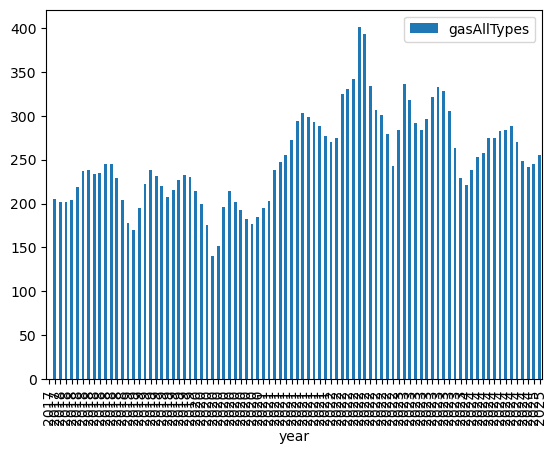

In [134]:
cim.plot.bar(x="year",y="gasAllTypes")

### Semi-Annual Data

In [12]:
dfCSemiA.columns

Index(['series_id', 'year', 'period', 'value', 'footnote_codes', 'area',
       'season', 'periodicity', 'item', 'areaName', 'seasonName',
       'periodicityName', 'itemName'],
      dtype='object')

In [13]:
dfCSemiA.head()

,series_id,year,period,value,footnote_codes,area,season,periodicity,item,areaName,seasonName,periodicityName,itemName
1064655,CUUSS48BAA0,1997,S01,523.7,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064656,CUUSS48BAA0,1997,S02,530.5,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064657,CUUSS48BAA0,1997,S03,527.1,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064658,CUUSS48BAA0,1998,S01,535.1,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064659,CUUSS48BAA0,1998,S02,544.5,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base


In [145]:
dfCSemiA["year"].value_counts()

year
2019    186
2018    186
2020    183
2022    180
2023    178
2021    177
2017    175
2024    170
2012    153
2016    153
2015    153
2014    153
2013    153
2011    153
2010    153
1998    135
2009    135
2008    135
2007    135
2006    135
2005    135
2004    135
2003    135
2002    135
2001    135
2000    135
1999    135
1997    129
Name: count, dtype: int64

In [146]:
dfCSemiA.loc[dfCSemiA["year"] == 2024]

,series_id,year,period,value,footnote_codes,area,season,periodicity,item,areaName,seasonName,periodicityName,itemName
1064736,CUUSS48BAA0,2024,S01,1084.767,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064737,CUUSS48BAA0,2024,S02,1099.867,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064738,CUUSS48BAA0,2024,S03,1092.317,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064820,CUUSS48BSA0,2024,S01,325.308,NaN,S48B,U,S,SA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items
1064821,CUUSS48BSA0,2024,S02,329.837,NaN,S48B,U,S,SA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items
1064822,CUUSS48BSA0,2024,S03,327.572,NaN,S48B,U,S,SA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items
1064904,CUUSS48BSA0E,2024,S01,233.744,NaN,S48B,U,S,SA0E,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,Energy
1064905,CUUSS48BSA0E,2024,S02,228.174,NaN,S48B,U,S,SA0E,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,Energy
1064906,CUUSS48BSA0E,2024,S03,230.959,NaN,S48B,U,S,SA0E,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,Energy
1064988,CUUSS48BSA0L1E,2024,S01,341.275,NaN,S48B,U,S,SA0L1E,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items less food and energy


In [14]:
dfCSemiA["itemName"].value_counts()

itemName
All items - old base                             84
Alcoholic beverages                              84
Housing                                          84
Shelter                                          84
All items                                        84
Nondurables                                      84
Nondurables less food                            84
Nondurables less food and beverages              84
Services                                         84
Services less rent of shelter                    84
Services less medical care services              84
Transportation                                   84
Private transportation                           84
Food away from home                              84
Rent of primary residence                        84
Owners' equivalent rent of residences            84
Owners' equivalent rent of primary residence     84
Motor fuel                                       84
Gasoline (all types)                             84
Gas

In [16]:
h=dfCSemiA.loc[dfCSemiA["itemName"] == "Housing"]

In [17]:
h.shape

(84, 13)

In [18]:
h["year"].value_counts()

year
1997    3
1998    3
2023    3
2022    3
2021    3
2020    3
2019    3
2018    3
2017    3
2016    3
2015    3
2014    3
2013    3
2012    3
2011    3
2010    3
2009    3
2008    3
2007    3
2006    3
2005    3
2004    3
2003    3
2002    3
2001    3
2000    3
1999    3
2024    3
Name: count, dtype: int64

In [19]:
h.loc[h["year"] == 2023]

,series_id,year,period,value,footnote_codes,area,season,periodicity,item,areaName,seasonName,periodicityName,itemName
1066535,CUUSS48BSAH,2023,S01,320.737,NaN,S48B,U,S,SAH,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,Housing
1066536,CUUSS48BSAH,2023,S02,331.505,NaN,S48B,U,S,SAH,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,Housing
1066537,CUUSS48BSAH,2023,S03,326.121,NaN,S48B,U,S,SAH,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,Housing


In [20]:
df.shape

(1095768, 9)

In [21]:
df["periodicity"].value_counts()

periodicity
R    881296
S    214472
Name: count, dtype: int64

In [22]:
dfS = df.loc[df["periodicity"] == "R"]

In [23]:
dfS.shape

(881296, 9)

In [24]:
dfS["year"].value_counts()

year
2023    41376
2018    41371
2019    41339
2024    41273
2020    41218
2021    41130
2022    41000
2017    32160
2016    30377
2015    30375
2012    30288
2014    30275
2013    30271
2011    30255
2010    30127
2009    27604
2008    27366
2007    27293
2006    27273
2005    27127
2004    27090
2003    27039
2002    26936
2001    26824
2000    26803
1999    26725
1998    26584
1997    20849
2025     2948
Name: count, dtype: int64

In [25]:
dfSC = dfS.loc[dfS["area"] == "S48B"]

In [26]:
def dfCol(df,col):
    display(df[col].value_counts())

dfCol(dfSC,"year")

year
2023    536
2018    524
2019    524
2022    521
2020    511
2024    507
2021    501
2017     73
2025     56
1997      2
Name: count, dtype: int64

In [27]:
dfS["area"].value_counts()

area
0000    237285
0100     24833
0300     24833
S000     24833
0200     24831
0400     24829
N000     23796
S49A     18572
S400     18572
S300     18572
S12A     18572
S100     18572
S23A     18566
S200     18560
N300     17715
N200     17715
N100     17713
N400     17712
D000     17709
A421     12891
D200     12890
D300     12885
S12B     12778
S49B     12734
S37A     12624
S11A     12609
S35B     12598
S37B     12573
S23B     12525
S49D     12243
S35C     12202
S35A     11626
S35E     11606
A210      8822
A311      8424
0120      5628
0350      5628
0230      5628
0490      5627
0370      5627
0240      5627
0360      5621
0480      5607
0110      5598
S24B      4159
S24A      3873
S49E      3862
S49F      3802
S49C      3801
S35D      3771
S49G      3768
S48B      3755
S48A      3699
A104       387
A212         2
A213         2
A425         2
A214         2
Name: count, dtype: int64

In [29]:
defAre["0480"]

'Mountain'

In [30]:
for a,n in defAre.items():
    print(f"{a:5s}  {n}")

0000   U.S. city average
0100   Northeast
0110   New England
0120   Middle Atlantic
0200   Midwest
0230   East North Central
0240   West North Central
0300   South
0350   South Atlantic
0360   East South Central
0370   West South Central
0400   West
0480   Mountain
0490   Pacific
A104   Pittsburgh, PA
A210   Cleveland-Akron, OH
A212   Milwaukee-Racine, WI
A213   Cincinnati-Hamilton, OH-KY-IN
A214   Kansas City, MO-KS
A311   Washington-Baltimore, DC-MD-VA-WV
A421   Los Angeles-Riverside-Orange County, CA
A425   Portland-Salem, OR-WA
D000   Size Class D
D200   Midwest - Size Class D
D300   South - Size Class D
N000   Size Class B/C
N100   Northeast - Size Class B/C
N200   Midwest - Size Class B/C
N300   South - Size Class B/C
N400   West - Size Class B/C
S000   Size Class A
S100   Northeast - Size Class A
S11A   Boston-Cambridge-Newton, MA-NH
S12A   New York-Newark-Jersey City, NY-NJ-PA
S12B   Philadelphia-Camden-Wilmington, PA-NJ-DE-MD
S200   Midwest - Size Class A
S23A   Chicago-Naperv

### Monthly vs Semi-Annual

In [14]:
dfCMnly

,series_id,year,period,value,footnote_codes,area,season,periodicity,item,areaName,seasonName,periodicityName,itemName
818759,CUURS48BAA0,2017,M11,862.370,NaN,S48B,U,R,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Monthly,All items - old base
818760,CUURS48BAA0,2018,M01,866.683,NaN,S48B,U,R,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Monthly,All items - old base
818761,CUURS48BAA0,2018,M03,868.977,NaN,S48B,U,R,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Monthly,All items - old base
818762,CUURS48BAA0,2018,M05,874.161,NaN,S48B,U,R,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Monthly,All items - old base
818763,CUURS48BAA0,2018,M07,872.684,NaN,S48B,U,R,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Monthly,All items - old base
...,...,...,...,...,...,...,...,...,...,...,...,...,...
822509,CUURS48BSS47016,2024,M10,300.887,NaN,S48B,U,R,SS47016,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Monthly,"Gasoline, unleaded premium"
822510,CUURS48BSS47016,2024,M11,280.895,NaN,S48B,U,R,SS47016,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Monthly,"Gasoline, unleaded premium"
822511,CUURS48BSS47016,2024,M12,274.421,NaN,S48B,U,R,SS47016,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Monthly,"Gasoline, unleaded premium"
822512,CUURS48BSS47016,2024,M13,291.932,NaN,S48B,U,R,SS47016,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Monthly,"Gasoline, unleaded premium"


In [13]:
dfCSemiA

,series_id,year,period,value,footnote_codes,area,season,periodicity,item,areaName,seasonName,periodicityName,itemName
1064655,CUUSS48BAA0,1997,S01,523.700,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064656,CUUSS48BAA0,1997,S02,530.500,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064657,CUUSS48BAA0,1997,S03,527.100,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064658,CUUSS48BAA0,1998,S01,535.100,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
1064659,CUUSS48BAA0,1998,S02,544.500,NaN,S48B,U,S,AA0,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,All items - old base
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1068905,CUUSS48BSS47016,2023,S02,323.459,NaN,S48B,U,S,SS47016,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,"Gasoline, unleaded premium"
1068906,CUUSS48BSS47016,2023,S03,325.207,NaN,S48B,U,S,SS47016,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,"Gasoline, unleaded premium"
1068907,CUUSS48BSS47016,2024,S01,283.955,NaN,S48B,U,S,SS47016,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,"Gasoline, unleaded premium"
1068908,CUUSS48BSS47016,2024,S02,299.910,NaN,S48B,U,S,SS47016,"Denver-Aurora-Lakewood, CO",Not Seasonally Adjusted,Semi-Annual,"Gasoline, unleaded premium"


In [15]:
dfCMnlyN = dfCMnly.copy()

In [16]:
def mapper(val):
    if val < "M07":
        s= "S01"
    elif val <= "M12":
        s= "S02"
    else:
        s="S03"
    return s

dfCMnlyN["Semi-A"] = dfCMnlyN["period"].map(mapper)

In [ ]:
dfCMnlyN.head(30)

In [18]:
dfCMnlyN.columns

Index(['series_id', 'year', 'period', 'value', 'footnote_codes', 'area',
       'season', 'periodicity', 'item', 'areaName', 'seasonName',
       'periodicityName', 'itemName', 'Semi-A'],
      dtype='object')

In [26]:
mn=dfCMnlyN.groupby(["areaName","itemName","year","Semi-A"],as_index=False).sum(numeric_only=True)

In [28]:
sa=dfCSemiA.groupby(["areaName","itemName","year","period"],as_index=False).sum(numeric_only=True)


In [27]:
mn

,areaName,itemName,year,Semi-A,value,footnote_codes
0,"Denver-Aurora-Lakewood, CO",Alcoholic beverages,2017,S02,199.143,0.0
1,"Denver-Aurora-Lakewood, CO",Alcoholic beverages,2018,S01,598.193,0.0
2,"Denver-Aurora-Lakewood, CO",Alcoholic beverages,2018,S02,614.935,0.0
3,"Denver-Aurora-Lakewood, CO",Alcoholic beverages,2018,S03,202.187,0.0
4,"Denver-Aurora-Lakewood, CO",Alcoholic beverages,2019,S01,610.721,0.0
...,...,...,...,...,...,...
1394,"Denver-Aurora-Lakewood, CO",Utility (piped) gas service,2018,S02,956.244,0.0
1395,"Denver-Aurora-Lakewood, CO",Utility (piped) gas service,2018,S03,160.788,0.0
1396,"Denver-Aurora-Lakewood, CO",Utility (piped) gas service,2019,S01,936.484,0.0
1397,"Denver-Aurora-Lakewood, CO",Utility (piped) gas service,2019,S02,868.446,0.0


In [29]:
sa

,areaName,itemName,year,period,value,footnote_codes
0,"Denver-Aurora-Lakewood, CO",Alcoholic beverages,1997,S01,131.900,0.0
1,"Denver-Aurora-Lakewood, CO",Alcoholic beverages,1997,S02,133.600,0.0
2,"Denver-Aurora-Lakewood, CO",Alcoholic beverages,1997,S03,132.700,0.0
3,"Denver-Aurora-Lakewood, CO",Alcoholic beverages,1998,S01,136.900,0.0
4,"Denver-Aurora-Lakewood, CO",Alcoholic beverages,1998,S02,136.500,0.0
...,...,...,...,...,...,...
4250,"Denver-Aurora-Lakewood, CO",Utility (piped) gas service,2018,S02,159.374,0.0
4251,"Denver-Aurora-Lakewood, CO",Utility (piped) gas service,2018,S03,160.788,0.0
4252,"Denver-Aurora-Lakewood, CO",Utility (piped) gas service,2019,S01,156.081,0.0
4253,"Denver-Aurora-Lakewood, CO",Utility (piped) gas service,2019,S02,144.741,0.0


In [30]:
mn.columns

Index(['areaName', 'itemName', 'year', 'Semi-A', 'value', 'footnote_codes'], dtype='object')

In [48]:
def check(row):
    year=row["year"]
    item=row["itemName"]
    per=row["Semi-A"]
    valmn=row["value"]
    valsa=sa.loc[(sa["year"]==year) & (sa["period"] == per) & (sa["itemName"]==item),"value"].values.tolist()
    if len(valsa) == 1:
        valsa=valsa[0]
        scal=6
        if per == "S03":
            scal=1
        if item == "Energy":
            print(item,year,per,valmn,valsa,valmn/scal-valsa)
    else:
        print(item,year,per,valsa)
    

mn.apply(check,axis=1)

Alcoholic beverages 2025 S01 []
All items 2025 S01 []
All items - old base 2025 S01 []
All items less energy 2025 S01 []
All items less food and energy 2025 S01 []
All items less medical care 2025 S01 []
All items less shelter 2025 S01 []
Apparel 2025 S01 []
Cereals and bakery products 2025 S01 []
Commodities 2025 S01 []
Commodities less food 2025 S01 []
Commodities less food and beverages 2025 S01 []
Dairy and related products 2025 S01 []
Durables 2025 S01 []
Education and communication 1997 S02 []
Education and communication 2025 S01 []
Education and communication commodities 2025 S01 []
Education and communication services 2025 S01 []
Energy 2017 S02 181.894 182.854 -152.53833333333336
Energy 2018 S01 1134.752 189.125 0.00033333333331597714
Energy 2018 S02 1175.489 195.915 -0.00016666666664377772
Energy 2018 S03 192.52 192.52 0.0
Energy 2019 S01 1070.623 178.437 0.00016666666667219943
Energy 2019 S02 1122.704 187.117 0.00033333333334439885
Energy 2019 S03 182.777 182.777 0.0
Energy 

0       None
1       None
2       None
3       None
4       None
        ... 
1394    None
1395    None
1396    None
1397    None
1398    None
Length: 1399, dtype: object

In [45]:
dfCMnlyN.loc[dfCMnlyN["itemName"] == "Energy",["itemName","period","Semi-A","value"]]

,itemName,period,Semi-A,value
818861,Energy,M12,S02,181.894
818862,Energy,M01,S01,181.422
818863,Energy,M02,S01,181.605
818864,Energy,M03,S01,182.669
818865,Energy,M04,S01,188.248
818866,Energy,M05,S01,197.449
818867,Energy,M06,S01,203.359
818868,Energy,M07,S02,198.539
818869,Energy,M08,S02,198.914
818870,Energy,M09,S02,204.120
